# Importações

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.preprocessing import OneHotEncoder

In [51]:
df_airports = pd.read_csv('../data/raw/airports.csv')
df_airports_id_numerico = pd.read_csv('../data/raw/T_MASTER_CORD.csv')
df_airlines = pd.read_csv('../data/raw/airlines.csv')
df_flights = pd.read_csv('../data/raw/flights.csv')

C:\Users\Pichau\AppData\Local\Temp\ipykernel_17112\993589427.py:4: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv('../data/raw/flights.csv')


In [52]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Verificando estatisticas descritivas e Ajustando tabelas

## Tabela AIRLINES

In [53]:
print(f'Número de linhas e colunas: {df_airlines.shape}')
df_airlines.head()

Número de linhas e colunas: (14, 2)


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [54]:
df_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   IATA_CODE  14 non-null     str  
 1   AIRLINE    14 non-null     str  
dtypes: str(2)
memory usage: 669.0 bytes


In [55]:
print(f'Valores nulos: \n{df_airlines.isnull().sum()} \n')
print(f'Valores duplicados: {df_airlines.duplicated().sum()}')

Valores nulos: 
IATA_CODE    0
AIRLINE      0
dtype: int64 

Valores duplicados: 0


| Não há necessidade de tratamento na tabela 

### Salvando novo dataframe

In [56]:
df_airlines.to_csv('../data/processed/airlines_ajustado.csv', index=False)

## Tabela Airports

Já identifiquei que na tabela de voos há registros com o id do aeroporto ao inves do IATA CODE, por esse motivo se faz necessario cruzar a tabela de aeroportos com um depara de ID.

In [57]:
df_airports = df_airports.merge(
    df_airports_id_numerico[['AIRPORT_IATA_CODE', 'AIRPORT_ID']],
    left_on='IATA_CODE',
    right_on='AIRPORT_IATA_CODE',
    how='left'
).drop(columns=['AIRPORT_IATA_CODE'])
df_airports['AIRPORT_ID'] = df_airports['AIRPORT_ID'].astype('Int64')
df_airports['AIRPORT_ID'] = df_airports['AIRPORT_ID'].astype('str')


In [58]:
print(f'Número de linhas e colunas: {df_airports.shape}')
df_airports.head()

Número de linhas e colunas: (322, 8)


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE,AIRPORT_ID
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040,10135
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190,10136
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919,10140
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183,10141
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447,10146


In [59]:
df_airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IATA_CODE   322 non-null    str    
 1   AIRPORT     322 non-null    str    
 2   CITY        322 non-null    str    
 3   STATE       322 non-null    str    
 4   COUNTRY     322 non-null    str    
 5   LATITUDE    319 non-null    float64
 6   LONGITUDE   319 non-null    float64
 7   AIRPORT_ID  322 non-null    str    
dtypes: float64(2), str(6)
memory usage: 37.5 KB


In [60]:
print(f'Valores nulos: \n{df_airports.isnull().sum()} \n')
print(f'Valores duplicados: {df_airports.duplicated().sum()}\n')

Valores nulos: 
IATA_CODE     0
AIRPORT       0
CITY          0
STATE         0
COUNTRY       0
LATITUDE      3
LONGITUDE     3
AIRPORT_ID    0
dtype: int64 

Valores duplicados: 0



| Foi Verificado valores nulos tanto na latitude quanto na longitude

### Verificando impacto

In [61]:
df_airports_nulos = df_airports.query('LATITUDE.isnull()')

In [62]:
quantidade_de_voos_sem_coord = df_flights[
    df_flights['ORIGIN_AIRPORT'].isin(df_airports_nulos['IATA_CODE'])
].shape[0]
percentual_de_voos_sem_coord = df_flights['ORIGIN_AIRPORT'].isin(
    df_airports_nulos['IATA_CODE']
).mean()

print(f'Quantidade de voos sem coordenadas: {quantidade_de_voos_sem_coord} de {df_flights.shape[0]} voos \nPercentual: {percentual_de_voos_sem_coord:.2%}')    

Quantidade de voos sem coordenadas: 4605 de 5819079 voos 
Percentual: 0.08%


| A quantidade de voos com esses aeroportos é menos de 1%, sendo assim irei apenas remove-los do dataset, já que a qualidade de dados é mais importante que a quantidade e o volume dos ausentes é bem pequeno.

OBS: Valores de altitute e longitude são quase como valores categoricos, ou seja não faz muito sentido aplicar técnica de preenchimento, seja por média, valor acima, valor abaixo etc

### Retirando aeroportos sem coordenadas

In [63]:
df_airports_ajustado = df_airports[~df_airports['IATA_CODE'].isin(df_airports_nulos['IATA_CODE'])]

### Salvando novo dataframe

In [64]:
df_airports_ajustado.to_csv('../data/processed/airports_ajustado.csv', index=False)

## Tabela Flights

In [65]:
print(f'Número de linhas e colunas: {df_flights.shape}')
df_flights.head()

Número de linhas e colunas: (5819079, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
df_flights.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
                        ...   
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
Length: 31, dtype: object

In [67]:
print(f'Valores nulos: \n{df_flights.isnull().sum()} \n')
print(f'Valores duplicados: {df_flights.duplicated().sum()}')

Valores nulos: 
YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
                        ...   
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
Length: 31, dtype: int64 

Valores duplicados: 0


| Será necessario tratar os tipos e os valores nulos

### Tratando tipos

In [68]:
df_flights['SCHEDULED_DEPARTURE'] = df_flights['SCHEDULED_DEPARTURE'].astype('Int64')
df_flights['SCHEDULED_DEPARTURE'] = df_flights['SCHEDULED_DEPARTURE'].replace(2400, 0)
df_flights['SCHEDULED_DEPARTURE'] = pd.to_datetime(df_flights['SCHEDULED_DEPARTURE'].astype(str).str.zfill(4), format='%H%M').dt.time

df_flights['DEPARTURE_TIME'] = df_flights['DEPARTURE_TIME'].astype('Int64')
df_flights['DEPARTURE_TIME'] = df_flights['DEPARTURE_TIME'].replace(2400, 0)
df_flights['DEPARTURE_TIME']    = pd.to_datetime(df_flights['DEPARTURE_TIME'].astype(str).str.zfill(4), format='%H%M').dt.time

df_flights['WHEELS_OFF'] = df_flights['WHEELS_OFF'].astype('Int64')
df_flights['WHEELS_OFF'] = df_flights['WHEELS_OFF'].replace(2400, 0)
df_flights['WHEELS_OFF'] = pd.to_datetime(df_flights['WHEELS_OFF'].astype(str).str.zfill(4), format='%H%M').dt.time

df_flights['WHEELS_ON'] = df_flights['WHEELS_ON'].astype('Int64')
df_flights['WHEELS_ON'] = df_flights['WHEELS_ON'].replace(2400, 0)
df_flights['WHEELS_ON'] = pd.to_datetime(df_flights['WHEELS_ON'].astype(str).str.zfill(4), format='%H%M').dt.time

df_flights['SCHEDULED_ARRIVAL'] = df_flights['SCHEDULED_ARRIVAL'].astype('Int64')
df_flights['SCHEDULED_ARRIVAL'] = df_flights['SCHEDULED_ARRIVAL'].replace(2400, 0)
df_flights['SCHEDULED_ARRIVAL_DT'] = pd.to_datetime(df_flights['SCHEDULED_ARRIVAL'].astype('Int64').astype(str).str.zfill(4), format='%H%M', errors='coerce')
df_flights['SCHEDULED_ARRIVAL'] = (df_flights['SCHEDULED_ARRIVAL_DT'].dt.time)

df_flights['ARRIVAL_TIME'] = df_flights['ARRIVAL_TIME'].astype('Int64')
df_flights['ARRIVAL_TIME'] = df_flights['ARRIVAL_TIME'].replace(2400, 0)
df_flights['ARRIVAL_TIME_DT'] = pd.to_datetime(df_flights['ARRIVAL_TIME'].astype('Int64').astype(str).str.zfill(4),format='%H%M', errors='coerce')
df_flights['ARRIVAL_TIME'] = (df_flights['ARRIVAL_TIME_DT'].dt.time)

df_flights['DEPARTURE_DELAY'] = df_flights['DEPARTURE_DELAY'].astype('Int64')
df_flights['TAXI_OUT'] = df_flights['TAXI_OUT'].astype('Int64')
df_flights['SCHEDULED_TIME'] = df_flights['SCHEDULED_TIME'].astype('Int64')
df_flights['ELAPSED_TIME'] = df_flights['ELAPSED_TIME'].astype('Int64')

df_flights['AIR_TIME'] = df_flights['AIR_TIME'].astype('Int64')
df_flights['TAXI_IN'] = df_flights['TAXI_IN'].astype('Int64')
df_flights['ARRIVAL_DELAY'] = df_flights['ARRIVAL_DELAY'].astype('Int64')


### Tratando valores ausentes

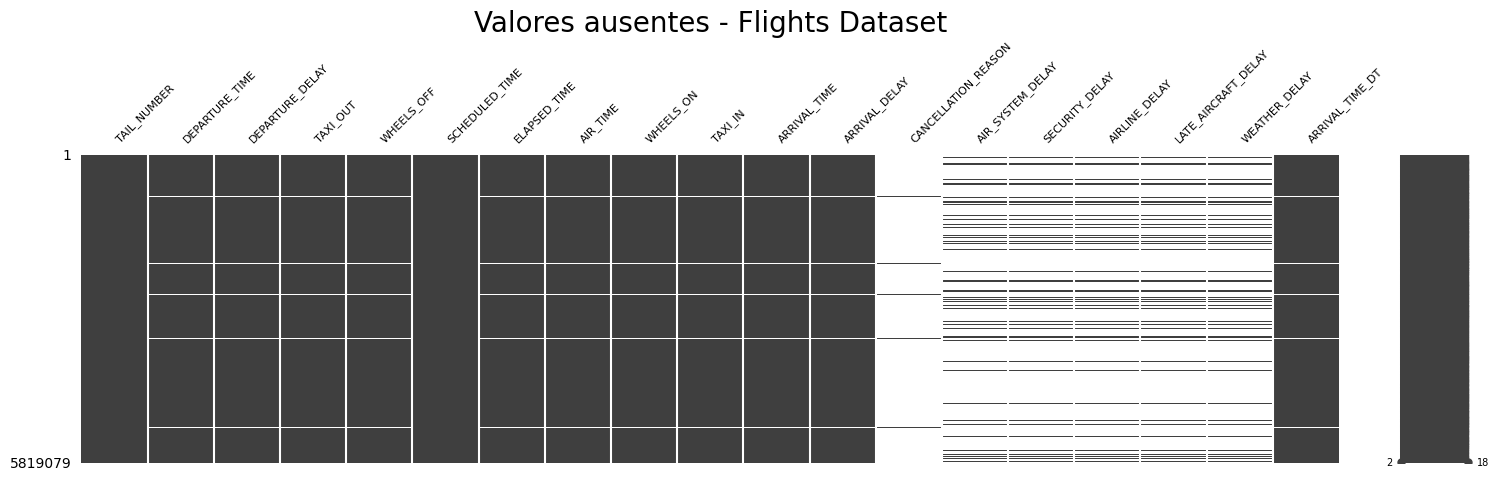

In [69]:
cols_nulos = (
    df_flights.isnull()
    .sum()
)

cols_nulos = cols_nulos[cols_nulos > 0].index
ax = msno.matrix(
        df_flights[cols_nulos], 
        figsize=(18,4),
        fontsize=8
    )
ax.get_figure().axes[0].tick_params(axis='x', rotation=45)
plt.title('Valores ausentes - Flights Dataset', fontsize=20)
plt.show()

### Tratando atrasos

Tratando atrasos nulos quando o voo não foi cancelado

In [70]:
quantidade_de_voos_cancelados = df_flights.query('CANCELLED == 1').shape[0]
quantidade_de_voos_cancelados_sem_atraso= df_flights.query('CANCELLED == 1').ARRIVAL_DELAY.isnull().sum()
quantidade_de_voos_desviados = df_flights.query('DIVERTED == 1').shape[0]
quantidade_de_voos_desviados_com_chegada = df_flights.query('DIVERTED == 1 & ARRIVAL_DELAY.notnull()').shape[0]
quantidade_de_voos_desviados_com_chegada_sem_atraso = df_flights.query('DIVERTED == 1 & ARRIVAL_DELAY.notnull()').ARRIVAL_DELAY.isnull().sum()

print(f'Houve um total de {quantidade_de_voos_cancelados} voos cancelados')
print(f'Houve um total de {quantidade_de_voos_cancelados_sem_atraso} voos cancelados sem informação de atraso')
print('--------------------------------')
print(f'Houve um total de {quantidade_de_voos_desviados} voos desviados.')
print(f'Houve um total de {quantidade_de_voos_desviados_com_chegada} voos desviados com informação de chegada')
print(f'Houve um total de {quantidade_de_voos_desviados_com_chegada_sem_atraso} voos desviados com chegada e sem informação de atraso')
print('--------------------------------')
print(f'''Resumo: Todos os voos cancelados não possuem informação de atraso, o que é esperado. 
Porém os voos desviados que chegaram também não possuem informação de atraso, mas deveria, pois o desvio pode causar atrasos.''')

Houve um total de 89884 voos cancelados
Houve um total de 89884 voos cancelados sem informação de atraso
--------------------------------
Houve um total de 15187 voos desviados.
Houve um total de 0 voos desviados com informação de chegada
Houve um total de 0 voos desviados com chegada e sem informação de atraso
--------------------------------
Resumo: Todos os voos cancelados não possuem informação de atraso, o que é esperado. 
Porém os voos desviados que chegaram também não possuem informação de atraso, mas deveria, pois o desvio pode causar atrasos.


In [71]:
# Calcula diferença em minutos entre chegada real e prevista
df_flights['DIFERENCA_MINUTOS'] = (
    (
        df_flights['ARRIVAL_TIME_DT']
        - df_flights['SCHEDULED_ARRIVAL_DT']
    )
    .dt.total_seconds()
    .div(60)
)

# Ajusta casos de virada de dia
df_flights.loc[
    df_flights['DIFERENCA_MINUTOS'] > 720,
    'DIFERENCA_MINUTOS'
] -= 1440

df_flights.loc[
    df_flights['DIFERENCA_MINUTOS'] < -720,
    'DIFERENCA_MINUTOS'
] += 1440

# Converte para inteiro nullable
df_flights['DIFERENCA_MINUTOS'] = (
    df_flights['DIFERENCA_MINUTOS']
    .round()
    .astype('Int64')
)

In [72]:

# Preenche ARRIVAL_DELAY nulo apenas para voos desviados
df_flights.loc[
    (df_flights['ARRIVAL_DELAY'].isna())
    &
    (df_flights['DIVERTED'] == 1),
    'ARRIVAL_DELAY'
] = df_flights.loc[
    (df_flights['ARRIVAL_DELAY'].isna())
    &
    (df_flights['DIVERTED'] == 1),
    'DIFERENCA_MINUTOS'
]

# Converte ARRIVAL_DELAY para inteiro nullable
df_flights['ARRIVAL_DELAY'] = (
    df_flights['ARRIVAL_DELAY']
    .round()
    .astype('Int64')
)

In [73]:
df_flights

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,SCHEDULED_ARRIVAL_DT,ARRIVAL_TIME_DT,DIFERENCA_MINUTOS
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,00:05:00,23:54:00,-11,21,00:15:00,205,194,169,1448,04:04:00,4,04:30:00,04:08:00,-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 04:30:00,1900-01-01 04:08:00,-22
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,00:10:00,00:02:00,-8,12,00:14:00,280,279,263,2330,07:37:00,4,07:50:00,07:41:00,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 07:50:00,1900-01-01 07:41:00,-9
2,2015,1,1,4,US,840,N171US,SFO,CLT,00:20:00,00:18:00,-2,16,00:34:00,286,293,266,2296,08:00:00,11,08:06:00,08:11:00,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 08:06:00,1900-01-01 08:11:00,5
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,00:20:00,00:15:00,-5,15,00:30:00,285,281,258,2342,07:48:00,8,08:05:00,07:56:00,-9,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 08:05:00,1900-01-01 07:56:00,-9
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,00:25:00,00:24:00,-1,11,00:35:00,235,215,199,1448,02:54:00,5,03:20:00,02:59:00,-21,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 03:20:00,1900-01-01 02:59:00,-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,23:59:00,23:55:00,-4,22,00:17:00,320,298,272,2611,07:49:00,4,08:19:00,07:53:00,-26,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 08:19:00,1900-01-01 07:53:00,-26
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,23:59:00,23:55:00,-4,17,00:12:00,227,215,195,1617,04:27:00,3,04:46:00,04:30:00,-16,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 04:46:00,1900-01-01 04:30:00,-16
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,23:59:00,23:50:00,-9,17,00:07:00,221,222,197,1598,04:24:00,8,04:40:00,04:32:00,-8,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 04:40:00,1900-01-01 04:32:00,-8
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,23:59:00,23:53:00,-6,10,00:03:00,161,157,144,1189,03:27:00,3,03:40:00,03:30:00,-10,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1900-01-01 03:40:00,1900-01-01 03:30:00,-10


### Criando coluna para saber se o voo teve atraso

In [74]:
df_flights['DELAY'] = df_flights['ARRIVAL_DELAY'] > 0

### Tratando Cancelados

Analisando apenas os voos não cancelados:

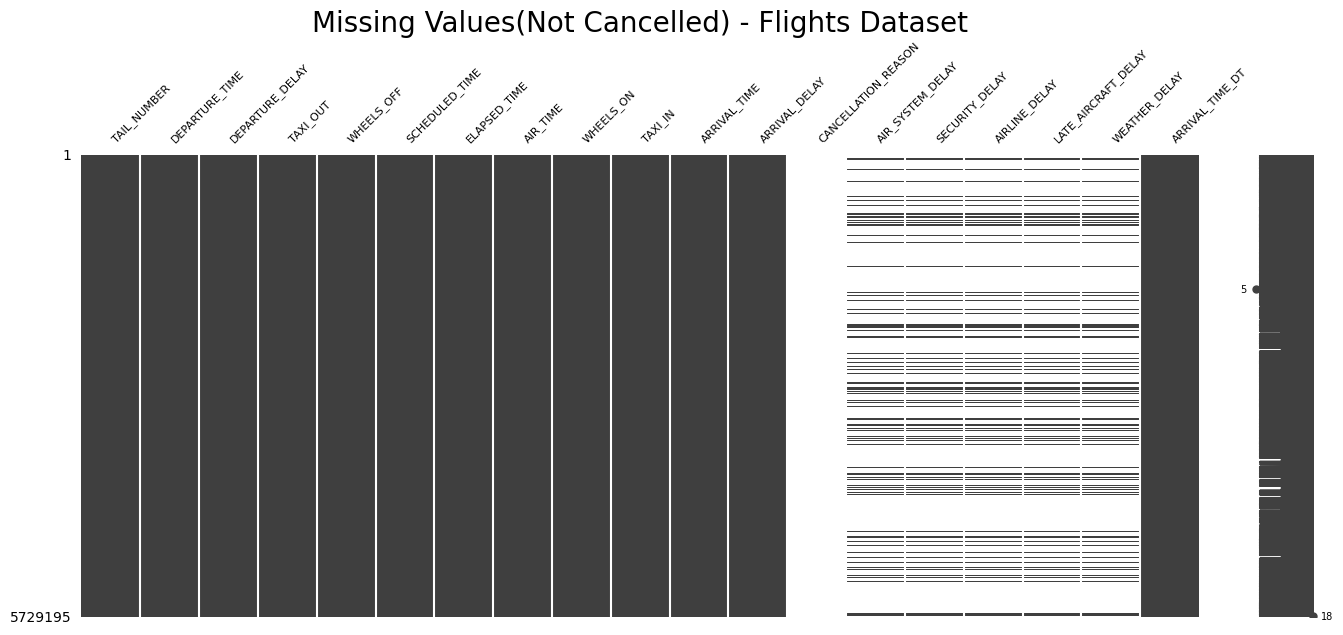

In [75]:
df_not_cancelled = df_flights[df_flights['CANCELLED'] == 0]
ax = msno.matrix(df_not_cancelled[cols_nulos], figsize=(16,6), fontsize=8)
ax.get_figure().axes[0].tick_params(axis='x', rotation=45)
plt.title('Missing Values(Not Cancelled) - Flights Dataset', fontsize=20)
plt.show()

Analisando apenas os voos cancelados:

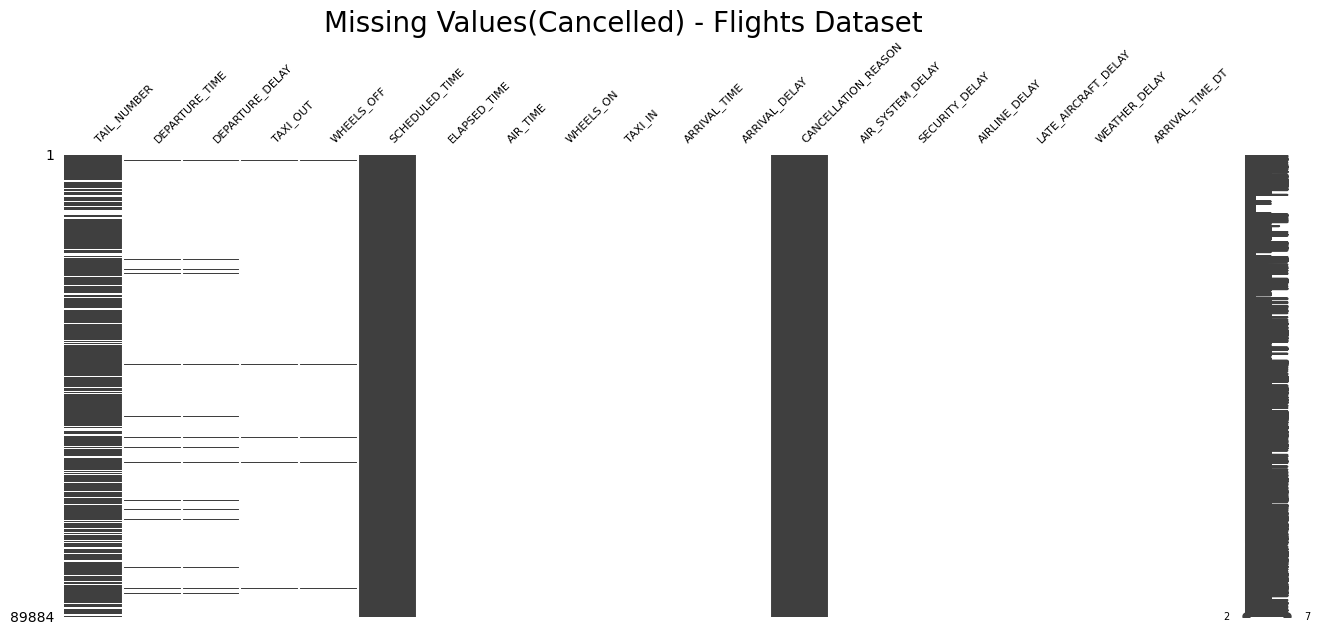

In [76]:
df_cancelled = df_flights[df_flights['CANCELLED'] == 1]
ax = msno.matrix(df_cancelled[cols_nulos], figsize=(16,6), fontsize=8)
ax.get_figure().axes[0].tick_params(axis='x', rotation=45)
plt.title('Missing Values(Cancelled) - Flights Dataset', fontsize=20)
plt.show()

- As colunas relacionadas à operação do voo deveria trazer valores nulos quando o voo é cancelado.
- A coluna CANCELLATION_REASON, por ser categórica, vou transforma-la em variáveis numéricas utilizando encoding.

Irei tratar os dois casos abaixo

In [77]:
cols_operacionais = [
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'WHEELS_OFF'
]

df_flights.loc[
    df_flights['CANCELLED'] == 1,
    cols_operacionais
] = None

In [78]:
# Substituindo valores do motivo do cancelamento
mapping_cancelamento = {'A': 'AIRLINE', 'B': 'WEATHER', 'C': 'NATIONAL AIR SYSTEM', 'D': 'SECURITY'}
df_flights['CANCELLATION_REASON'] = (
    df_flights['CANCELLATION_REASON']
    .map(mapping_cancelamento)
)
# Aplicando o OneHotEncoder para a coluna de motivo de cancelamento
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc = one_hot_encoder.fit_transform(df_flights[['CANCELLATION_REASON']])

encoded_cols = one_hot_encoder.get_feature_names_out(
    ['CANCELLATION_REASON']
)
# DataFrame encoded
df_encoded = pd.DataFrame(
    enc,
    columns=encoded_cols,
    index=df_flights.index
)
df_flights_ajustado = pd.concat([df_flights, df_encoded], axis=1)
df_flights_ajustado.drop(columns=['CANCELLATION_REASON', 'CANCELLATION_REASON_nan'], inplace=True)

In [79]:
df_flights_ajustado['ORIGIN_AIRPORT'] = df_flights_ajustado['ORIGIN_AIRPORT'].astype(str)
df_flights_ajustado['DESTINATION_AIRPORT'] = df_flights_ajustado['DESTINATION_AIRPORT'].astype(str)
df_flights_ajustado['AIRLINE'] = df_flights_ajustado['AIRLINE'].astype(str)

df_flights_ajustado['CANCELLATION_REASON_AIRLINE'] = df_flights_ajustado['CANCELLATION_REASON_AIRLINE'].astype('boolean')
df_flights_ajustado['CANCELLATION_REASON_NATIONAL AIR SYSTEM'] = df_flights_ajustado['CANCELLATION_REASON_NATIONAL AIR SYSTEM'].astype('boolean')
df_flights_ajustado['CANCELLATION_REASON_SECURITY'] = df_flights_ajustado['CANCELLATION_REASON_SECURITY'].astype('boolean')
df_flights_ajustado['CANCELLATION_REASON_WEATHER'] = df_flights_ajustado['CANCELLATION_REASON_WEATHER'].astype('boolean')

### Salvando novo dataframe

In [80]:
df_flights_ajustado.to_csv('../data/processed/flights_ajustado.csv', index=False)

## Juntando as 3 bases

In [81]:
df_airports_origin = df_airports_ajustado.rename(columns={'IATA_CODE': 'IATA_CODE_ORIGIN', 'AIRPORT': 'AIRPORT_ORIGIN', 'CITY': 'CITY_ORIGIN', 'STATE': 'STATE_ORIGIN', 'COUNTRY': 'COUNTRY_ORIGIN', 'LATITUDE': 'LATITUDE_ORIGIN', 'LONGITUDE': 'LONGITUDE_ORIGIN', 'AIRPORT_ID': 'AIRPORT_ID_ORIGIN'})
df_airports_dest = df_airports_ajustado.rename(columns={'IATA_CODE': 'IATA_CODE_DESTINATION', 'AIRPORT': 'AIRPORT_DESTINATION', 'CITY': 'CITY_DESTINATION', 'STATE': 'STATE_DESTINATION', 'COUNTRY': 'COUNTRY_DESTINATION', 'LATITUDE': 'LATITUDE_DESTINATION', 'LONGITUDE': 'LONGITUDE_DESTINATION', 'AIRPORT_ID': 'AIRPORT_ID_DESTINATION'})
df_airlines = df_airlines.rename(columns={'IATA_CODE': 'IATA_CODE_AIRLINE', 'AIRLINE': 'AIRLINE_NAME'})

df_airports_origin['IATA_CODE_ORIGIN'] = df_airports_origin['IATA_CODE_ORIGIN'].astype(str)
df_airports_dest['IATA_CODE_DESTINATION'] = df_airports_dest['IATA_CODE_DESTINATION'].astype(str)
df_airlines['IATA_CODE_AIRLINE'] = df_airlines['IATA_CODE_AIRLINE'].astype(str)

In [82]:
# ==========================================
# ORIGIN
# ==========================================

# Merge por IATA
df_origin = df_flights_ajustado.merge(
    df_airports_origin,
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE_ORIGIN',
    how='left'
)

# Identifica sem match
mask_origin = df_origin['IATA_CODE_ORIGIN'].isna()

# Apenas linhas sem match
fallback_origin = (
    df_flights_ajustado.loc[mask_origin, ['ORIGIN_AIRPORT']]
    .merge(
        df_airports_origin,
        left_on='ORIGIN_AIRPORT',
        right_on='AIRPORT_ID_ORIGIN',
        how='left'
    )
)

# Atualiza apenas linhas faltantes
cols_airport_origin = df_airports_origin.columns

df_origin.loc[mask_origin, cols_airport_origin] = (
    fallback_origin[cols_airport_origin].values
)

df_origin.drop(columns='IATA_CODE_ORIGIN', inplace=True)
df_origin.drop(columns='AIRPORT_ID_ORIGIN', inplace=True)

In [83]:
# ==========================================
# DESTINATION
# ==========================================

df_dest = df_origin.merge(
    df_airports_dest,
    left_on='DESTINATION_AIRPORT',
    right_on='IATA_CODE_DESTINATION',
    how='left'
)

mask_dest = df_dest['IATA_CODE_DESTINATION'].isna()

fallback_dest = (
    df_origin.loc[mask_dest, ['DESTINATION_AIRPORT']]
    .merge(
        df_airports_dest,
        left_on='DESTINATION_AIRPORT',
        right_on='AIRPORT_ID_DESTINATION',
        how='left'
    )
)

cols_airport_dest = df_airports_dest.columns

df_dest.loc[mask_dest, cols_airport_dest] = (
    fallback_dest[cols_airport_dest].values
)

df_dest.drop(columns='IATA_CODE_DESTINATION', inplace=True)
df_dest.drop(columns='AIRPORT_ID_DESTINATION', inplace=True)

In [84]:
df_final = (
    df_dest
    .merge(
        df_airlines,
        left_on='AIRLINE',
        right_on='IATA_CODE_AIRLINE',
        how='left'
    )
    .drop(columns='IATA_CODE_AIRLINE')
)

In [86]:
df_final.to_parquet('../data/processed/flights.parquet', index=False)